# Gabor creation walkthrough
Covers everything up to the point where stimuli are handed to AlexNet.
The manifold itself lives in activation space and is built in the next notebook.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../../../../VPL_orientation_DCNN/model').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from GaborCreater import gabor_patch, noise_gabor_patch, test_sample_generator

# paper defaults
SIZE  = 227
SF    = 40
SIGMA = 50
SD_1  = 10 / 255
SD_2  = 15 / 100
PHASE = 0
THETA = 35   # reference orientation (deg)

## 1 — Clean Gabor patch
```
gabor[x,y] = ( sin(2π(x·sinθ + y·cosθ)/sf + phase) · contrast · gaussian_envelope + 1 ) / 2
```

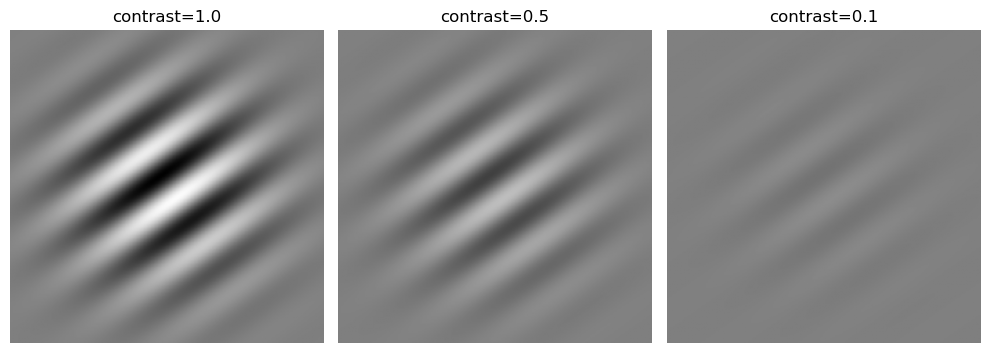

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, c in zip(axes, [1.0, 0.5, 0.1]):
    g = gabor_patch(SIZE, THETA, SF, PHASE, c, SIGMA)
    ax.imshow(g, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'contrast={c}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2 — Inside `noise_gabor_patch`: the three arrays
All three arrays are generated at **block resolution** `(size//8+1)² = 29×29` and then tiled to pixel resolution.

- **additive_noise**: one Gaussian(0, SD_1) value per block, added to every signal block
- **pure_noise**: one Gaussian(0.5, SD_2) value per block, used to fully replace noise blocks
- **idx_noise**: Bernoulli(p/100) per block — `True` means the whole block is replaced by `pure_noise`

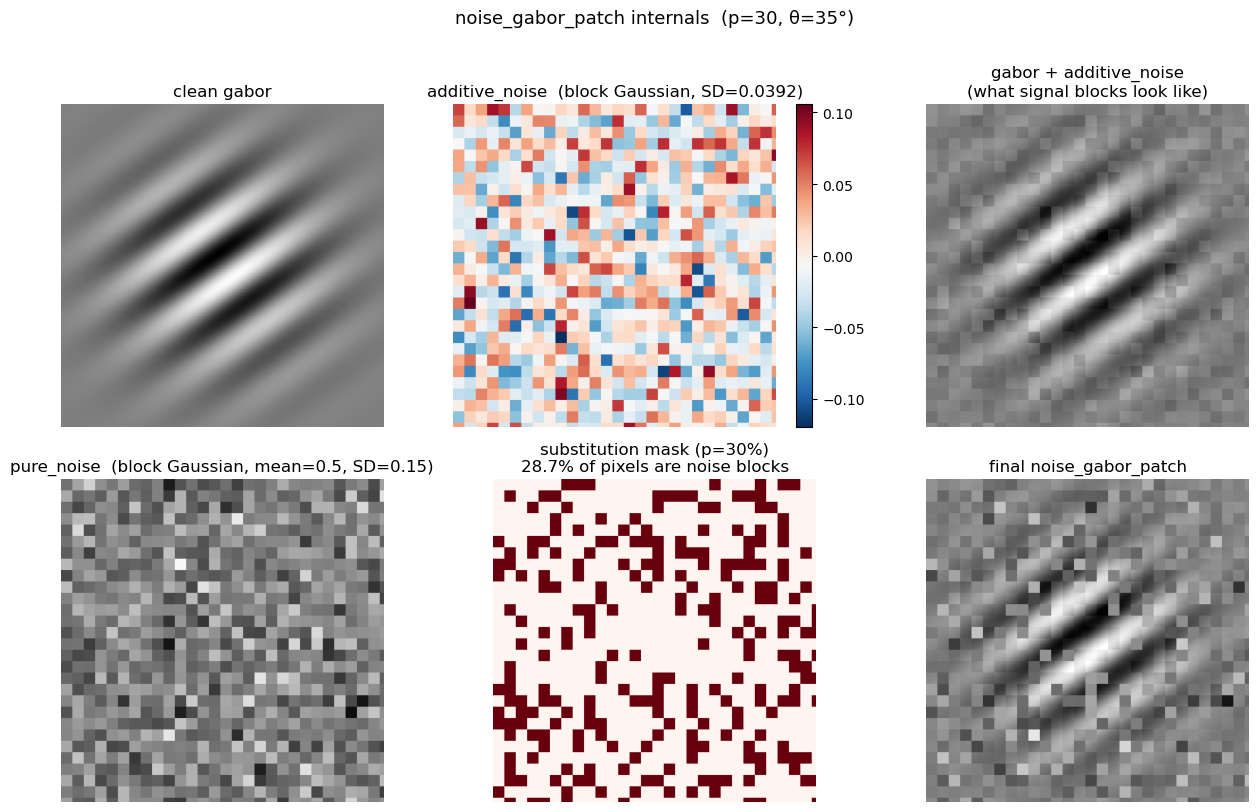

In [4]:
np.random.seed(0)
p = 30

gabor = gabor_patch(SIZE, THETA, SF, PHASE, 1.0, SIGMA)
tempsize = (SIZE // 8 + 1, SIZE // 8 + 1)  # (29, 29)

additive_noise = (np.random.randn(*tempsize) * SD_1).repeat(8, axis=0).repeat(8, axis=1)[:SIZE, :SIZE]
pure_noise     = (0.5 + np.random.randn(*tempsize) * SD_2).repeat(8, axis=0).repeat(8, axis=1)[:SIZE, :SIZE]
idx_noise      = (np.random.rand(*tempsize).repeat(8, axis=0).repeat(8, axis=1)[:SIZE, :SIZE]) < p / 100
noise_gabor    = idx_noise * pure_noise + ~idx_noise * (gabor + additive_noise)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

axes[0, 0].imshow(gabor, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('clean gabor')

im = axes[0, 1].imshow(additive_noise, cmap='RdBu_r')
plt.colorbar(im, ax=axes[0, 1])
axes[0, 1].set_title(f'additive_noise  (block Gaussian, SD={SD_1:.4f})')

axes[0, 2].imshow(gabor + additive_noise, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title('gabor + additive_noise\n(what signal blocks look like)')

axes[1, 0].imshow(pure_noise, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title(f'pure_noise  (block Gaussian, mean=0.5, SD={SD_2})')

axes[1, 1].imshow(idx_noise, cmap='Reds', vmin=0, vmax=1)
axes[1, 1].set_title(f'substitution mask (p={p}%)\n{idx_noise.mean()*100:.1f}% of pixels are noise blocks')

axes[1, 2].imshow(noise_gabor, cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title('final noise_gabor_patch')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle(f'noise_gabor_patch internals  (p={p}, θ={THETA}°)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3 — Effect of noise level `p`
The 8 values used in the paper: `[0.005, 1, 5, 10, 15, 30, 50, 75]`

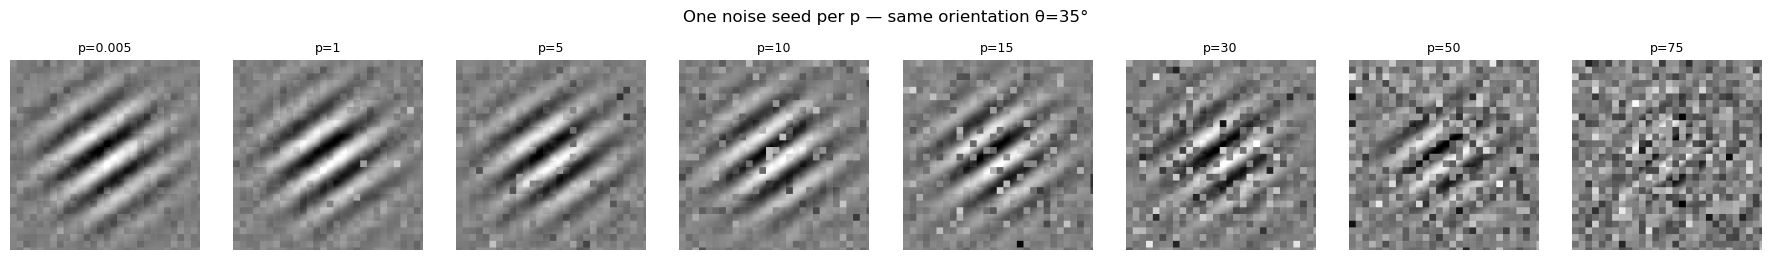

In [ ]:
p_values = [0.005, 1, 5, 10, 15, 30, 50, 75]
np.random.seed(1)

fig, axes = plt.subplots(1, len(p_values), figsize=(18, 2.5))
for ax, p in zip(axes, p_values):
    img = noise_gabor_patch(SIZE, p, THETA, SF, PHASE, 1.0, SIGMA, SD_1=SD_1, SD_2=SD_2)
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'p={p}', fontsize=9)
    ax.axis('off')
plt.suptitle('One noise seed per p — same orientation θ=35°', y=1.02)
plt.tight_layout()
plt.show()

## 4 — Multiple noise draws at the same stimulus condition
Each draw produces one independent noisy image.
These are the 100 images (per orientation, per condition) that will be fed to AlexNet.
The resulting 100 activation vectors — one per image — are what form the manifold cloud.

**The manifold does not exist here.** It only exists after the forward pass.

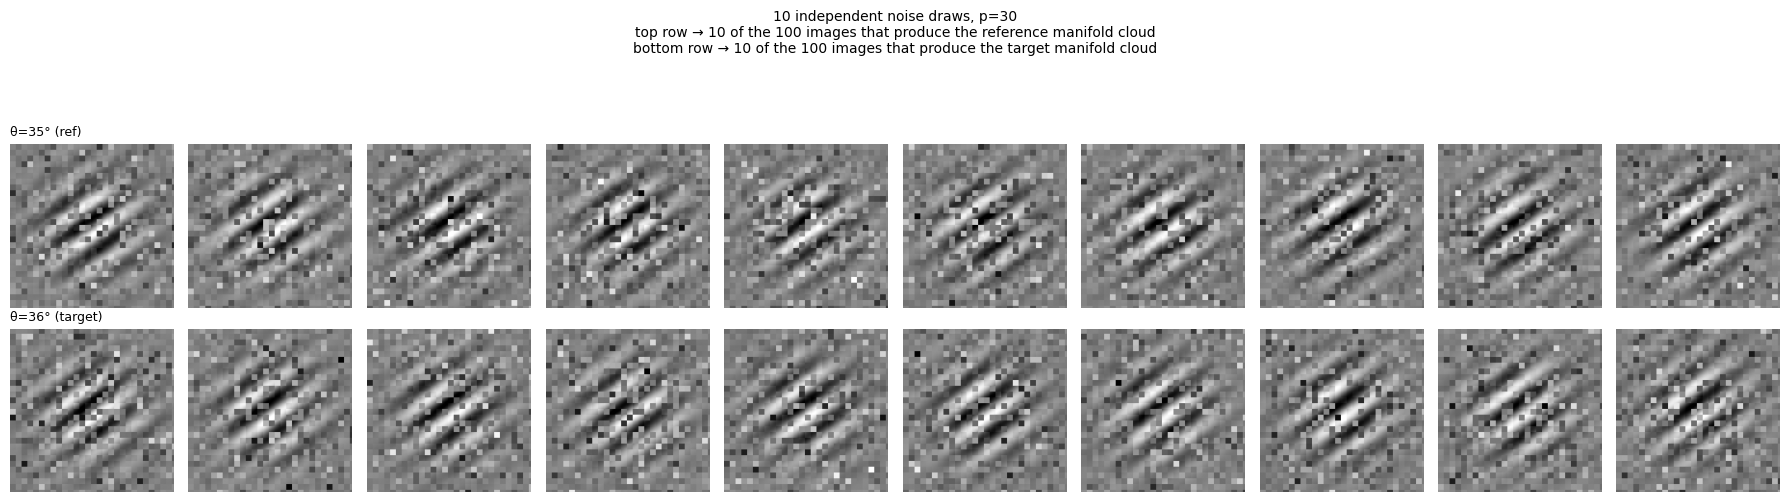

In [10]:
p_display = 30
n_trials  = 10

fig, axes = plt.subplots(2, n_trials, figsize=(18, 5))
for i in range(n_trials):
    for row, theta in enumerate([THETA, THETA + 1]):
        img = noise_gabor_patch(SIZE, p_display, theta, SF, PHASE, 1.0, SIGMA, SD_1=SD_1, SD_2=SD_2)
        axes[row, i].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, i].axis('off')

axes[0, 0].set_title(f'θ={THETA}° (ref)', fontsize=9, loc='left')
axes[1, 0].set_title(f'θ={THETA+1}° (target)', fontsize=9, loc='left')

plt.suptitle(
    f'{n_trials} independent noise draws, p={p_display}\n'
    f'top row → 10 of the 100 images that produce the reference manifold cloud\n'
    f'bottom row → 10 of the 100 images that produce the target manifold cloud\n',
    y=1.04, fontsize=10
)
plt.tight_layout()
plt.show()

## 5 — `test_sample_generator`: the actual tensor pairs fed to AlexNet
Returns `(input1, input2, label)` tensors of shape `(batchsize, 3, 227, 227)`, scaled to [0,255].
- `input1` = target (θ+1° if flag=0)
- `input2` = reference (θ)
- Both channels are identical (grayscale tiled to 3 channels)

input1 shape: torch.Size([4, 3, 227, 227])
input2 shape: torch.Size([4, 3, 227, 227])
labels:       tensor([0., 0., 0., 0.])


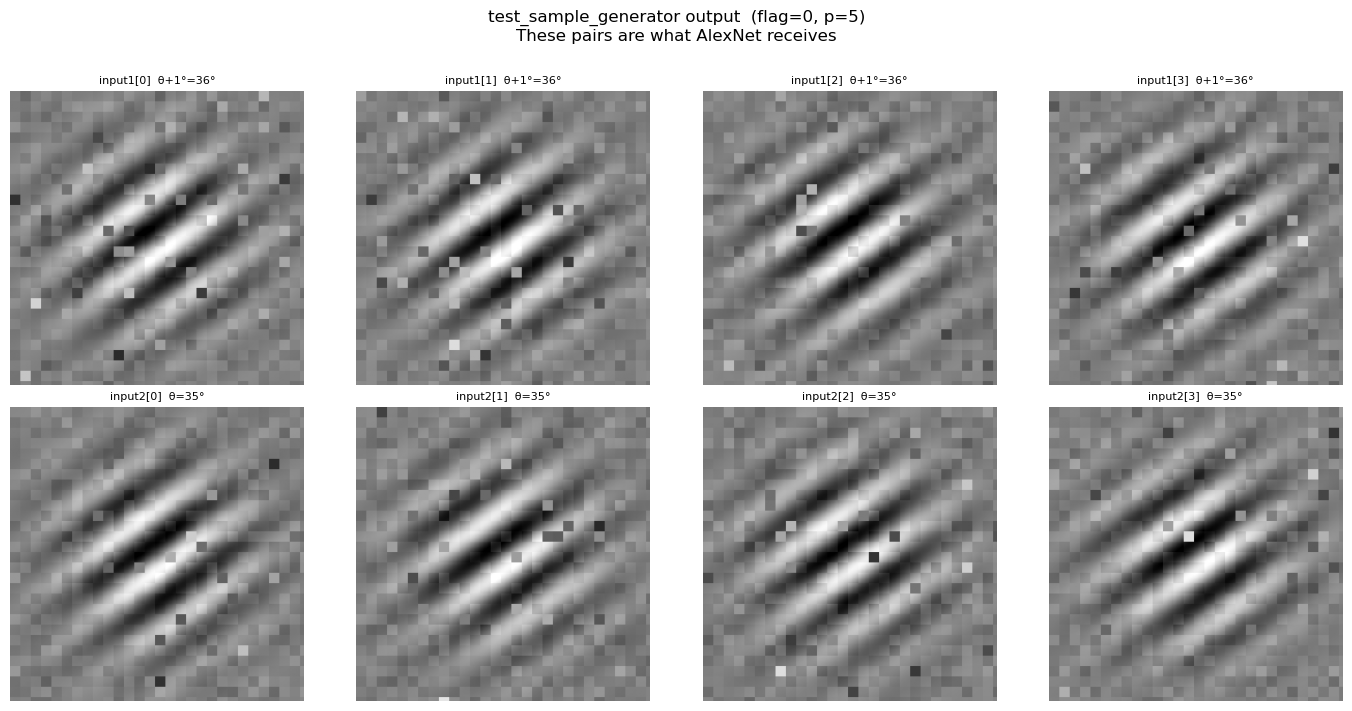

In [7]:
input1, input2, labels = test_sample_generator(batchsize=4, p=5, theta=THETA, contrast=1.0, flag=0)

print('input1 shape:', input1.shape)   # (4, 3, 227, 227)
print('input2 shape:', input2.shape)
print('labels:      ', labels)         # all 0 for flag=0

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(input1[i, 0].numpy() / 255, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'input1[{i}]  θ+1°={THETA+1}°', fontsize=8)
    axes[1, i].imshow(input2[i, 0].numpy() / 255, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'input2[{i}]  θ={THETA}°', fontsize=8)
    for r in range(2):
        axes[r, i].axis('off')
plt.suptitle('test_sample_generator output  (flag=0, p=5)\nThese pairs are what AlexNet receives', y=1.01)
plt.tight_layout()
plt.show()

## 6 — Cascade: contrast → noise level → seed
A single figure showing the full stimulus-generation tree:

- **Row 0** — one clean Gabor at full contrast (the root).
- **Row 1** — two contrast variants of that Gabor, still noiseless.
- **Row 2** — each contrast variant ramifies into two noise levels.
- **Row 3** — each (contrast, noise) cell ramifies into two seeds (two independent noise draws of the same condition).

Total leaves: 2 contrasts × 2 noise levels × 2 seeds = 8 final images. The same `noise_gabor_patch` call is used throughout; the seed (`np.random.seed`) controls the noise sample at each leaf.

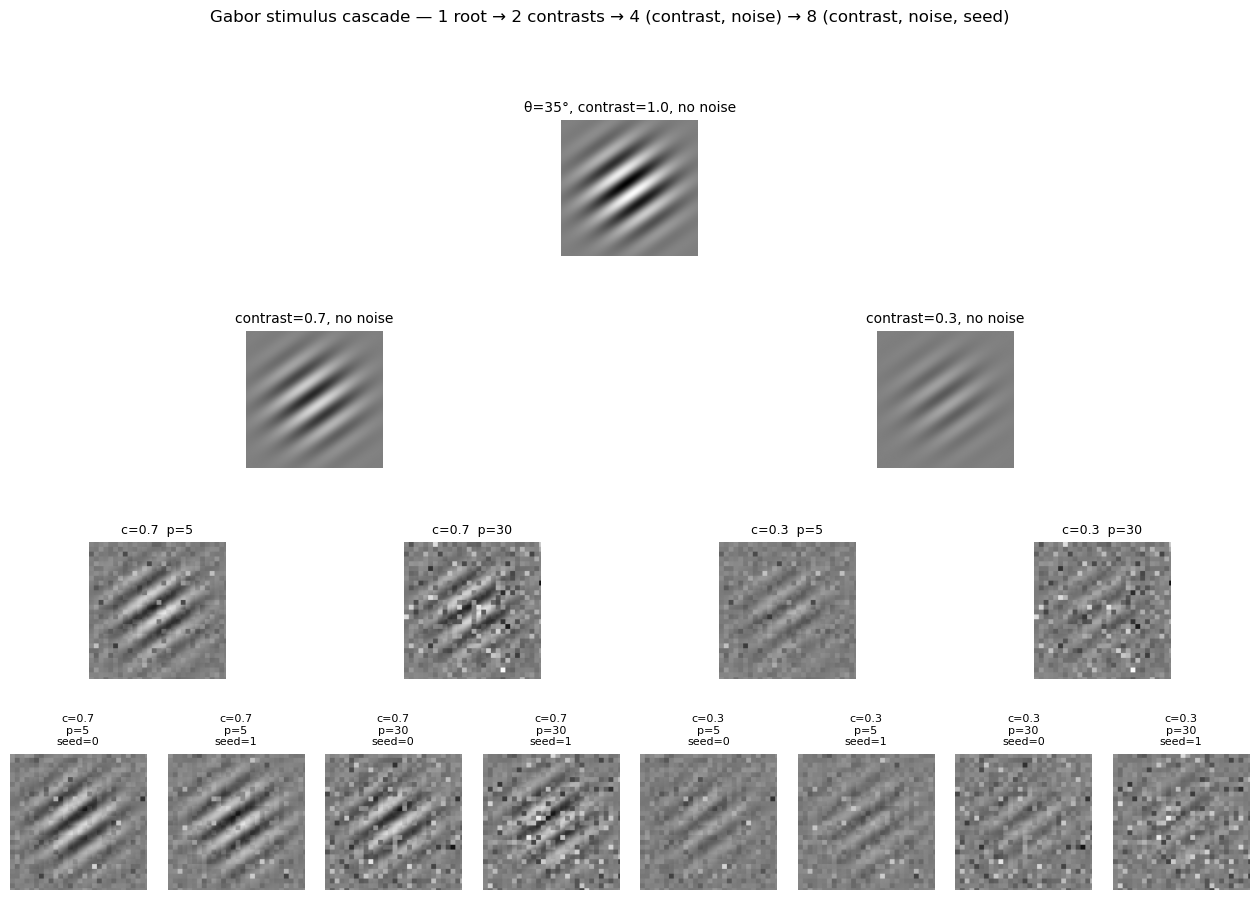

In [8]:
# Cascade levels — feel free to tweak
CONTRASTS = [0.7, 0.3]      # 2 contrast variants (after the root)
NOISE_PS  = [5, 30]         # 2 noise levels (after each contrast)
SEEDS     = [0, 1]          # 2 seeds (after each noise level)

# 8 columns → binary-tree positions:
#   Row 0 root spans cols 3-4 (center)
#   Row 1 contrasts span cols 1-2 and 5-6
#   Row 2 (contrast × noise) span cols 0-1, 2-3, 4-5, 6-7
#   Row 3 (contrast × noise × seed) each in its own column 0..7
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(4, 8, hspace=0.55, wspace=0.15)

# ---- Row 0: root ----
root_img = gabor_patch(SIZE, THETA, SF, PHASE, 1.0, SIGMA)
ax = fig.add_subplot(gs[0, 3:5])
ax.imshow(root_img, cmap='gray', vmin=0, vmax=1)
ax.set_title(f'θ={THETA}°, contrast=1.0, no noise', fontsize=10)
ax.axis('off')

# ---- Row 1: 2 contrasts (no noise) ----
row1_spans = [(1, 3), (5, 7)]
for (col_lo, col_hi), c in zip(row1_spans, CONTRASTS):
    g = gabor_patch(SIZE, THETA, SF, PHASE, c, SIGMA)
    ax = fig.add_subplot(gs[1, col_lo:col_hi])
    ax.imshow(g, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'contrast={c}, no noise', fontsize=10)
    ax.axis('off')

# ---- Row 2: 4 (contrast, noise level) — one example each ----
row2_spans = [(0, 2), (2, 4), (4, 6), (6, 8)]
i = 0
for c in CONTRASTS:
    for p in NOISE_PS:
        # Use a fixed "demo" seed for row 2 so each (c, p) is one
        # representative sample (any seed would do; we just pick one).
        np.random.seed(42)
        g = noise_gabor_patch(SIZE, p, THETA, SF, PHASE, c, SIGMA,
                              SD_1=SD_1, SD_2=SD_2)
        col_lo, col_hi = row2_spans[i]
        ax = fig.add_subplot(gs[2, col_lo:col_hi])
        ax.imshow(g, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'c={c}  p={p}', fontsize=9)
        ax.axis('off')
        i += 1

# ---- Row 3: 8 (contrast, noise level, seed) ----
i = 0
for c in CONTRASTS:
    for p in NOISE_PS:
        for seed in SEEDS:
            np.random.seed(seed)
            g = noise_gabor_patch(SIZE, p, THETA, SF, PHASE, c, SIGMA,
                                  SD_1=SD_1, SD_2=SD_2)
            ax = fig.add_subplot(gs[3, i])
            ax.imshow(g, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'c={c}\np={p}\nseed={seed}', fontsize=8)
            ax.axis('off')
            i += 1

fig.suptitle(
    'Gabor stimulus cascade — 1 root → 2 contrasts → 4 (contrast, noise) → 8 (contrast, noise, seed)',
    fontsize=12, y=0.99,
)
plt.show()